In this project about student's performance, I seek to explore how different factors are associated with students' final grades and how well these factors can be used to predict academic performance.

I divide the analysis into two parts. 

Part A explores the dataset, establishes a baseline predictive model, and identifies potentially important relationships between the available features and final grades.

Part B narrows the analysis to students' use of time, focusing on study time, sleep, attendance, extracurricular activities, and part-time employment.

The initial markdown cells document my exploratory thought process and preprocessing decisions before these steps are consolidated into a reproducible machine-learning pipeline.

In [71]:
import numpy as np
import pandas as pd
import os
import kagglehub

# Download/attach dataset
path = kagglehub.dataset_download(
    "harshadapatil31/student-performance-and-study-habits-dataset"
)

# See files in dataset
print(os.listdir(path))
df = pd.read_csv(os.path.join(path, 'student_performance_dataset.csv'))
df.head()

['student_performance_dataset.csv']


,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


In [72]:
print(df.info())
print(df.describe())

for col in df.select_dtypes(include="object"):
    print(col)
    print(df[col].value_counts(dropna=False))
    print()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   object 
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    object 
 6   internet_access             1000 non-null   object 
 7   extracurricular_activities  1000 non-null   object 
 8   part_time_job               1000 non-null   object 
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 93.9+ KB
None
        student_id  study_ti

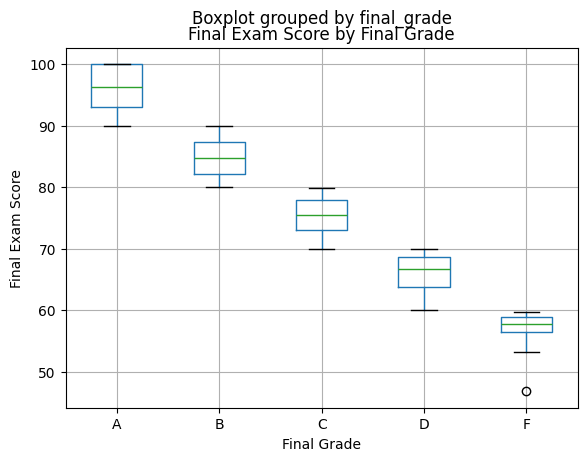

In [73]:
import matplotlib.pyplot as plt

df.boxplot(
    "final_exam_score",
    "final_grade"
)

plt.xlabel("Final Grade")
plt.ylabel("Final Exam Score")
plt.title("Final Exam Score by Final Grade")
plt.show()

From the graph, there is a strong relationship between final exam score and final grade, which suggests that the final exam score may be directly involved in determining final grade. I therefore will exclude it form the predictos to avoid potential target leakage and to ensure that the model predicts grades using information available indepedent of the final examination outcome.

<Axes: xlabel='parental_education'>

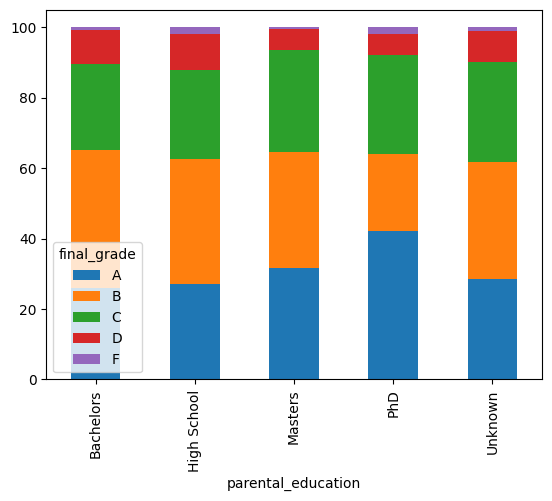

In [74]:
df_eda = df.copy()
df_eda["parental_education"] = (
    df_eda["parental_education"].fillna("Unknown")
)
counts = df_eda.groupby(["parental_education", "final_grade"]).size()
total = df_eda.groupby(['parental_education']).size()
percentages = round(counts / counts.groupby(level=0).transform("sum") * 100, 2)
percentage_table = percentages.unstack()
percentage_table.plot(kind='bar', stacked=True)


From bar graph, it appears that, less PhD, the final grades for the rest of the parent education categories are around the same. 
This lead me to a hypothesis that parental education is not strongly associated with the student's grade. 
Next I will conduct a hypothesis testing:
H0 = parental education and final grade are independent
H1 = parental education and final grade are dependent

In [75]:
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(counts.unstack())
print("p-value:", p)

p-value: 0.3963054993645445


At the 5% significance level, I fail to reject H0. There is insufficient evidence to conclude that parental education and final grade are associated in this dataset.

The EDA suggested **limited** overall association between parental education and final grade, while the postgraduate categories did showed some descriptive differences. 
In my first run of this project, I grouped Master's and PhD together as 'higher education' to reduce sparsity while retaining a distinction between undergraduate as 'university' and postgraduate education.

Now I'll begin the preprocessing

In [76]:
X = df.drop(columns=[
    "student_id",
    "final_exam_score",
    "final_grade"
])

y = df["final_grade"]

In [77]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

numeric_cols = [
    "study_time_hours",
    "attendance_percent",
    "sleep_hours",
    "previous_grade"
]

categorical_cols = [
    "gender",
    "internet_access",
    "extracurricular_activities",
    "part_time_job",
    "parental_education"
]


Initial approach:

Yes/No → manual mapping

Parental education → manually grouped (High School, University, Higher education and Unknown)

Missing education → Unknown

Education → manual OneHotEncoder

Encoded columns → manually concatenated


After running through X_train through the model and cross-validation, I've discovered that not much improvements were done for the model even as I group both education together. 

In addition to the fact that this required transformations to be manually repeated across training and test sets and that preprocessing outside cross-validation is harder to manage safely, I refactored preprocessing using ColumnTransformer and Pipeline instead, to allow preprocessing to be fitted independetly within each cross-validation fold.



In [78]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

numtransformer = StandardScaler()
cattransformer = Pipeline([
    ("imputer", SimpleImputer(
        strategy='constant',
        fill_value='Unknown'
    )),
    ("hoten", OneHotEncoder(
        handle_unknown="ignore"
    ))
])
preprocessor = ColumnTransformer([
    ("num", numtransformer, numeric_cols),
    ('cat', cattransformer, categorical_cols)
])

Since final grade consists of five discrete categories (A-F), this is a multiclass classification problem. I will be comparing four classification algorithms representing different modelling approaches.

Logistic Regression - A relatively simple, interpretable linear classifier and useful baseline
KNN - a distance-based classifier that predicts based on similar observations.
Decision Tree - capture non-linear relationships and is relatively interpretable.
Random Forest - an ensemble of decision treess that can reduce some of the overfitting problems of decision tree.

In [79]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

In [80]:
pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])


In [81]:
from sklearn.model_selection import cross_val_score

for name, pipeline in pipelines.items():
    
    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )
    print(name, scores.mean())



Logistic Regression 0.5662499999999999
KNN 0.4625
Decision Tree 0.42000000000000004
Random Forest 0.49749999999999994


In [82]:
for name, pipeline in pipelines.items():
    
    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="f1_macro"
    )
    print(name, scores.mean())


Logistic Regression 0.4534348010168877
KNN 0.29920740135871443
Decision Tree 0.3120734451952606
Random Forest 0.3347278004563377


From both scoring methods, logistic regression appear to be the best performing.
However, the decrease in score for f1_macro may hint that the model performance is not equally good across all 5 classes, possibly due to number of Fs being smaller than the rest.

In [83]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

for name, pipeline in pipelines.items():
    pred = cross_val_predict(
        pipeline,
        X_train,
        y_train,
        cv=5
    )
    labels = ['A', 'B', 'C', 'D', 'F']
    cm_df = pd.DataFrame(confusion_matrix(y_train, pred, labels=labels), index=labels, columns=labels)
    cm_df.index.name = "Actual"
    cm_df.columns.name = "Predicted"
    print(name)
    print(cm_df)

Logistic Regression
Predicted    A    B    C   D  F
Actual                         
A          155   66    6   0  0
B           58  166   56   3  0
C            5   80  109  14  1
D            0    8   39  22  2
F            0    0    5   4  1
KNN
Predicted    A    B   C  D  F
Actual                       
A          146   68  13  0  0
B           88  150  43  2  0
C           26  106  72  5  0
D            0   34  34  2  1
F            0    2   3  5  0
Decision Tree
Predicted    A    B   C   D  F
Actual                        
A          121   83  18   5  0
B           84  112  64  21  2
C           20   74  87  28  0
D            6   20  27  16  2
F            0    2   5   3  0
Random Forest
Predicted    A    B   C  D  F
Actual                       
A          144   70  13  0  0
B           65  151  64  3  0
C            9   92  99  9  0
D            0   18  49  4  0
F            0    0   7  3  0


From confusion matrix, It can be seen that model does not predict F students.

Running the model with LogisticRegression(max_iter=1000, class_weight='balanced') instead, this is the comparison:

Accuracy: 54.0%  
Macro F1: 46.7%

While the balancing improved minority-class recognition, it greatly diminished performance on the common class.
Since this project's objective is about overall grade prediction rather than specifically detecting students at risk, I will be using the non-balanced model of logistic regression instead.

In [84]:
from sklearn.model_selection import GridSearchCV
params = {
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10, 100]
    },

    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9, 11],
        "model__weights": ["uniform", "distance"]
    },

    "Decision Tree": {
        "model__max_depth": [None, 3, 5, 10],
        "model__min_samples_split": [2, 5, 10]
    },

    "Random Forest": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 5, 10],
        "model__min_samples_split": [2, 5]
    }
}

best_models = {}
for name, pipeline in pipelines.items():
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=params[name],
        cv=5,
        scoring='accuracy'
    )
    
    grid.fit(X_train,y_train)
        
    best_models[name] = grid.best_estimator_
    
    print(name)
    print("Best parameters:", grid.best_params_)
    print("Best CV accuracy:", grid.best_score_)
    print()
    


Logistic Regression
Best parameters: {'model__C': 100}
Best CV accuracy: 0.56875

KNN
Best parameters: {'model__n_neighbors': 11, 'model__weights': 'distance'}
Best CV accuracy: 0.4925

Decision Tree
Best parameters: {'model__max_depth': 5, 'model__min_samples_split': 10}
Best CV accuracy: 0.48125

Random Forest
Best parameters: {'model__max_depth': 5, 'model__min_samples_split': 5, 'model__n_estimators': 300}
Best CV accuracy: 0.5275000000000001



In conclusion, even after tuning for all the models, logistic regression remains the best performing.
Therefore, I'll be choosing logisitic regression as my selected model for this project.

In [85]:
final_model = best_models["Logistic Regression"]
y_pred = final_model.predict(X_test)

In [86]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

accuracy = accuracy_score(y_test, y_pred)
print("Test accuracy:", accuracy)
cmatrix = confusion_matrix(y_test, y_pred, labels=labels)
print("Confusion Matrix: \n", cmatrix)
print("Classification Report: \n", 
      classification_report(
    y_test,
    y_pred
))

Test accuracy: 0.635
Confusion Matrix: 
 [[41 16  0  0  0]
 [14 47 10  0  0]
 [ 1 16 33  1  1]
 [ 0  1 10  6  1]
 [ 0  0  1  1  0]]
Classification Report: 
               precision    recall  f1-score   support

           A       0.73      0.72      0.73        57
           B       0.59      0.66      0.62        71
           C       0.61      0.63      0.62        52
           D       0.75      0.33      0.46        18
           F       0.00      0.00      0.00         2

    accuracy                           0.64       200
   macro avg       0.54      0.47      0.49       200
weighted avg       0.64      0.64      0.63       200



Report: 
* Test accuracy: The tuned Logistic Regression achieved a mean 5-fold cross-validation accuracy of 56.9% and a final held-out test accuracy of 63.5%.
* Confusion Matrix: High recall rate on grades A, B and C, but failed on D and F. Specifically, 0 F students were found. This is to be expected however, as there are only 2 F students in the test set and 12 overall.

In [87]:
logreg = final_model.named_steps['model']
preprocessor = final_model.named_steps["preprocessor"]
print(logreg.classes_)
print(logreg.coef_.shape)
print(preprocessor.get_feature_names_out())

['A' 'B' 'C' 'D' 'F']
(5, 17)
['num__study_time_hours' 'num__attendance_percent' 'num__sleep_hours'
 'num__previous_grade' 'cat__gender_Female' 'cat__gender_Male'
 'cat__internet_access_No' 'cat__internet_access_Yes'
 'cat__extracurricular_activities_No'
 'cat__extracurricular_activities_Yes' 'cat__part_time_job_No'
 'cat__part_time_job_Yes' 'cat__parental_education_Bachelors'
 'cat__parental_education_High School' 'cat__parental_education_Masters'
 'cat__parental_education_PhD' 'cat__parental_education_Unknown']


In [88]:
coef_df = pd.DataFrame(
    logreg.coef_,
    index=logreg.classes_,
    columns=preprocessor.get_feature_names_out()
)
coef_df.T

,A,B,C,D,F
num__study_time_hours,2.894367,1.405168,0.044052,-1.295325,-3.048263
num__attendance_percent,1.537765,0.718754,0.096814,-0.584503,-1.768830
num__sleep_hours,0.556817,0.229202,0.099126,-0.412530,-0.472614
num__previous_grade,2.268531,1.107518,0.091319,-0.825304,-2.642065
cat__gender_Female,0.146639,0.458623,0.441510,0.101743,-1.148516
cat__gender_Male,0.151203,0.341389,0.325079,-0.152437,-0.665235
cat__internet_access_No,-1.187272,-0.438915,0.435762,0.207770,0.982655
cat__internet_access_Yes,1.485114,1.238928,0.330827,-0.258463,-2.796406
cat__extracurricular_activities_No,0.019434,0.481429,0.528579,0.134489,-1.163930
cat__extracurricular_activities_Yes,0.278409,0.318584,0.238011,-0.185182,-0.649821


In [89]:
print(coef_df[[
    "num__study_time_hours",
    "num__attendance_percent",
    "num__sleep_hours",
    "num__previous_grade"
]].T)

                                A         B         C         D         F
num__study_time_hours    2.894367  1.405168  0.044052 -1.295325 -3.048263
num__attendance_percent  1.537765  0.718754  0.096814 -0.584503 -1.768830
num__sleep_hours         0.556817  0.229202  0.099126 -0.412530 -0.472614
num__previous_grade      2.268531  1.107518  0.091319 -0.825304 -2.642065


From data above, I can infer that higher study time, attendance, sleep duration and previous grades are associated with the model being more likely to predict higher final grades. 
Study time and previous grade show particularly strong relationships, with large positive coefficients for A and large negative coefficients for F.

In [90]:
print(coef_df[[
    "cat__extracurricular_activities_No",
    "cat__extracurricular_activities_Yes",
    "cat__part_time_job_No",
    "cat__part_time_job_Yes"
]].T)

                                            A         B         C         D  \
cat__extracurricular_activities_No   0.019434  0.481429  0.528579  0.134489   
cat__extracurricular_activities_Yes  0.278409  0.318584  0.238011 -0.185182   
cat__part_time_job_No                0.965257  0.796601  0.557442 -0.505730   
cat__part_time_job_Yes              -0.667414  0.003411  0.209147  0.455037   

                                            F  
cat__extracurricular_activities_No  -1.163930  
cat__extracurricular_activities_Yes -0.649821  
cat__part_time_job_No               -1.813571  
cat__part_time_job_Yes              -0.000181  


From data above, 

Part time job: no-job students seem more associated with A/B predictions while those who have a job shifts the model relatively toward lower-grade predictions. 

Extracurricular activities: The coefficients don't show as clear or consistent a pattern, so no strong conclusion can be drawn currently.

These model coefficients suggest several relationships involving students' use of time, particularly study time, attendance, sleep, and part-time employment. Part B will investigate these relationships directly in the underlying data.

Part B

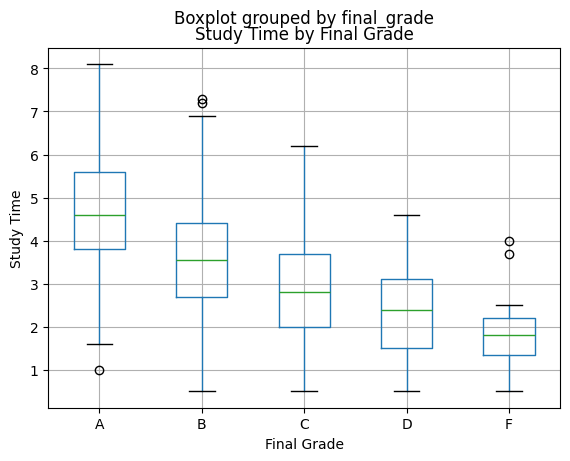

In [91]:
df.boxplot(
    "study_time_hours",
    "final_grade"
)

plt.xlabel("Final Grade")
plt.ylabel("Study Time")
plt.title("Study Time by Final Grade")
plt.show()

The box plot shows a strong positive association between study time and final grade, with students who spend more time studying generally receiving higher grades. 'A' students have an IQR of approximately 3.8–5.6 hours and a median of 4.5 hours, compared with 'F' students, whose IQR is approximately 1.5–2.4 hours with a median of 1.8 hours.

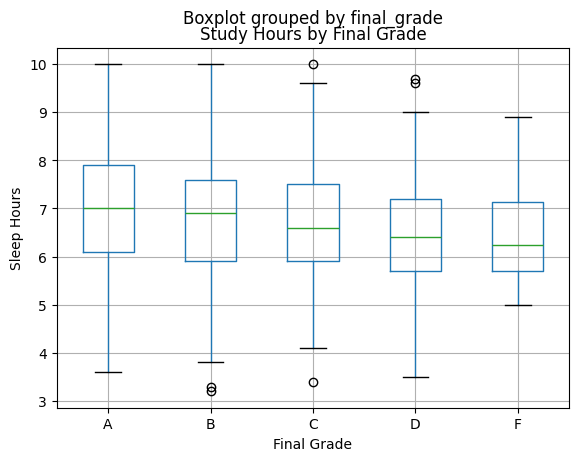

In [92]:
df.boxplot(
    "sleep_hours",
    "final_grade"
)

plt.xlabel("Final Grade")
plt.ylabel("Sleep Hours")
plt.title("Study Hours by Final Grade")
plt.show()

There appears to be only a weak relationship between sleep duration and final grade, where students generally have around the same hours of sleep of around 6-7.5hrs.

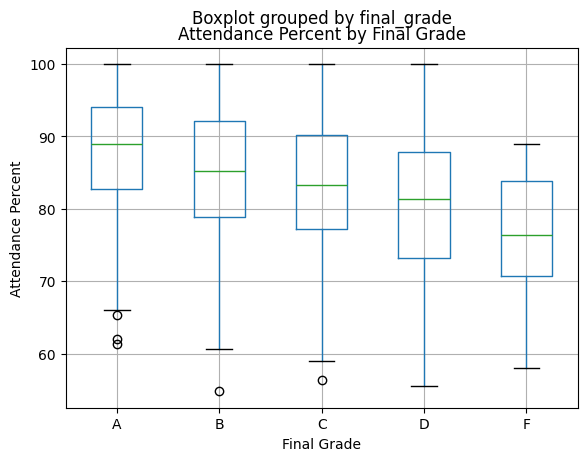

In [93]:
df.boxplot(
    "attendance_percent",
    "final_grade"
)

plt.xlabel("Final Grade")
plt.ylabel("Attendance Percent")
plt.title("Attendance Percent by Final Grade")
plt.show()

Box plot shows a positive association where students with higher grades tend to have a higher attendance percentages. However, high-performing students can still have relatively low attendance can also show that it is not a necesssary condition for high performance.

In [94]:
df.groupby('part_time_job')[time_cols].mean()

,study_time_hours,sleep_hours,attendance_percent
part_time_job,,,
No,3.589766,6.791667,84.784064
Yes,3.529430,6.816456,85.759494


Students with and without part-time jobs show relatively similar study time, sleep duration and attendance, suggesting that part-time employment is not associated with large differences in these measured time-use variables within this dataset.

In [95]:
df.groupby('extracurricular_activities')[time_cols].mean()

,study_time_hours,sleep_hours,attendance_percent
extracurricular_activities,,,
No,3.576636,6.792991,84.975701
Yes,3.566259,6.804371,85.179545


Surprisingly, neither part-time employment nor extracurricular participation was associated with substantial differences in study time, sleep duration, or attendance.

In [96]:
time_cols = [
    "study_time_hours",
    "sleep_hours",
    "attendance_percent"
]

df[time_cols].corr()

,study_time_hours,sleep_hours,attendance_percent
study_time_hours,1.000000,0.005594,-0.043712
sleep_hours,0.005594,1.000000,0.034089
attendance_percent,-0.043712,0.034089,1.000000


All three correlations are extremely close to zero.
No clear trade-off was observed among the time-related variables measured in this dataset.

Now I will look at how much predictive information about final grades is contained in students' time-related characteristics.

In [97]:
timerelated_cols = [
    "study_time_hours",
    "sleep_hours",
    "attendance_percent",
    "extracurricular_activities",
    "part_time_job"
]
X_time = df[timerelated_cols]
y = df['final_grade']
X_train_time, X_test_time, y_train_time, y_test_time = train_test_split(
    X_time,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [98]:
time_num_cols = [
    "study_time_hours",
    "sleep_hours",
    "attendance_percent"
]
time_cat_cols = [
    "extracurricular_activities",
    "part_time_job"
]
time_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), time_num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), time_cat_cols)
])

time_pipeline = Pipeline([
    ('preprocessor', time_preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

In [99]:
scores = cross_val_score(
    time_pipeline,
    X_train_time,
    y_train_time,
    cv=5,
    scoring="accuracy"
)

print(scores)
print(scores.mean())

[0.48125 0.51875 0.46875 0.48125 0.48125]
0.48624999999999996


There is a ~8% drop from the previous model

In [100]:
logregparams = {'model__C':[0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(
    estimator=time_pipeline,
    param_grid=logregparams,
    cv=5,
    scoring='accuracy'

)
grid.fit(X_train_time, y_train_time)
print("Best parameters:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

Best parameters: {'model__C': 100}
Best CV accuracy: 0.4875


In [101]:
best_time_model = grid.best_estimator_

y_pred_time = best_time_model.predict(X_test_time)

accuracy = accuracy_score(y_test_time, y_pred_time)
print("Test accuracy:", accuracy)
cmatrix = confusion_matrix(y_test_time, y_pred_time, labels=labels)
print("Confusion Matrix: \n", cmatrix)
print("Classification Report: \n", 
      classification_report(
    y_test_time,
    y_pred_time
))

Test accuracy: 0.525
Confusion Matrix: 
 [[41 14  2  0  0]
 [17 37 17  0  0]
 [ 5 23 22  2  0]
 [ 0  3 10  5  0]
 [ 0  0  1  1  0]]
Classification Report: 
               precision    recall  f1-score   support

           A       0.65      0.72      0.68        57
           B       0.48      0.52      0.50        71
           C       0.42      0.42      0.42        52
           D       0.62      0.28      0.38        18
           F       0.00      0.00      0.00         2

    accuracy                           0.53       200
   macro avg       0.44      0.39      0.40       200
weighted avg       0.52      0.53      0.52       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


From data above, removing the non-time variables reduced both CV and Test.
This shows that time variables do contain meaningful predictive information, but the broader feature set contains additional predictive information.

In [102]:
logreg_time = best_time_model.named_steps["model"]
preprocessor_time = best_time_model.named_steps["preprocessor"]
timecoef_df = pd.DataFrame(
    logreg_time.coef_,
    index=logreg_time.classes_,
    columns=preprocessor_time.get_feature_names_out()
)
timecoef_df.T

,A,B,C,D,F
num__study_time_hours,1.714547,0.675178,-0.129154,-0.932353,-1.328217
num__sleep_hours,0.408234,0.137914,0.026577,-0.348318,-0.224408
num__attendance_percent,0.941653,0.398170,0.050748,-0.401393,-0.989178
cat__extracurricular_activities_No,0.278817,0.579266,0.445886,-0.040993,-1.262976
cat__extracurricular_activities_Yes,0.183907,0.298183,0.191226,-0.199727,-0.473590
cat__part_time_job_No,0.821428,0.740567,0.526197,-0.491166,-1.597025
cat__part_time_job_Yes,-0.358704,0.136882,0.110916,0.250446,-0.139540


Part B CONCLUSION:

The predictive results largely support the patterns observed during EDA. The exploratory analysis suggested that (1) study time has a strong positive association with final grade, (2) attendance has a positive association with final grade, and (3) sleep duration has a comparatively weak association with final grade.

The time-only Logistic Regression model showed a similar pattern. Study time had the strongest and clearest ordered coefficients across grade categories, followed by attendance, while sleep duration had substantially smaller coefficients. This suggests that among the continuous time-related variables measured, study time and attendance provide more predictive information about final grades than sleep duration.

There was some evidence that not having a part-time job was associated with the model favouring higher-grade predictions. However, students with and without part-time jobs showed relatively small differences in their measured study time, sleep duration, and attendance. Therefore, the observed relationship between part-time employment and grades cannot be clearly explained by differences in these three variables alone.

No similarly clear pattern emerged for extracurricular participation, either from the exploratory comparisons or from the model coefficients.

Overall, the time-only model achieved a mean cross-validation accuracy of 48.75% and a test accuracy of 53%. This was lower than the broader model developed in Part A, suggesting that time-related characteristics contain useful predictive information but do not capture all of the information associated with students' final grades.



LIMITATIONS:

The dataset contains only 1000 students and is highly imbalanced across final-grade categories. In particular, only 12 students received an F, with 10 appearing in the training set and two in the test set. The final time-only model did not correctly identify the F students in the test set, making conclusions about performance on this class particularly unreliable.

The dataset also records several time commitments only as binary variables. For example, part time job indicates whether a student has a job but does not record the number of hours worked. A student could be working three hours/week while another is working 30 hours/week and still treated identically. The same limitation applies to extracurricular participation. This restricts the extent to which the dataset can represent students' actual allocation of time.

Furthermore, the dataset does not capture all uses of students' time in a day, such as activties commuting, leisure, screen time, socialising, or other responsibilities. Therefore, the near-zero correlations observed between study time, sleep, and attendance should not be interpreted as evidence that students face no trade-offs in their overall allocation of time.

Lastly, the analysis is observational. The relationships identified should therefore be interpreted as associations rather than casusation. For example, the results do not establish that increasing study time by itself would cause a student's final grade to improve.

OVERALL CONCLUSION

The objective of this study was to determine how certain factors in a student's life are associated with their academic performance, as measured by their final grades. The study then focused on students' time-related behaviours and commitments to determine whether they are associated with final grades.

From Part A, the broader analysis established that Logistic Regression performed best, with approximately 56.9% cross-validation accuracy and 63.5% test accuracy. Time-related factors such as study time and class attendance also showed stronger coefficients.

This motivated a deeper analysis of these factors in Part B, focusing specifically on study time, sleep, attendance, part-time employment, and extracurricular activities.

Results from Part B showed that study time had the strongest association with grades, while attendance also showed a clear positive association and sleep showed a weaker association. Part-time work and extracurricular activities did not show clear evidence of substantially changing the measured allocation of study time, sleep, or attendance.

Initially, I approached this as a "time allocation" study, but found that study time, sleep, and attendance were almost uncorrelated with one another. The data therefore did not show any clear trade-offs among these measured variables.

The time-only model achieved 48.75% cross-validation accuracy and 53% test accuracy, compared with 56.9% and 63.5%, respectively, for the broader model. This shows that time-related variables contain predictive information, but restricting the model to these variables reduces its performance. Therefore, they do not capture all of the predictive information available in the broader dataset.

Ultimately, this study cannot establish whether changing these factors would cause an improvement in students' academic performance, as the results demonstrate associations rather than causal effects.
